# Parsing Dates

In [2]:
import pandas as pd
import numpy as np
import datetime

np.random.seed(0)
landslides = pd.read_csv("../input/landslide-events-catalog.csv")

In [3]:
landslides.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


In [6]:
print(landslides['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: str


In [7]:
landslides['date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [8]:
# create a new column, date_parsed, with the parsed dates
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

In [9]:
landslides['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[us]

In [ ]:
# landslides['date_parsed'] = pd.to_datetime(landslides['date'], infer_datetime_format=True)

In [10]:
# get the day of the month from the date_parsed column
day_of_month_landslides = landslides['date_parsed'].dt.day
day_of_month_landslides.head()

0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: date_parsed, dtype: float64

(array([49., 54., 68., 70., 48., 47., 57., 41., 43., 40., 52., 80., 57.,
        54., 54., 66., 48., 79., 60., 52., 61., 52., 61., 48., 51., 30.,
        77., 52., 55., 53., 31.]),
 array([ 1.        ,  1.96774194,  2.93548387,  3.90322581,  4.87096774,
         5.83870968,  6.80645161,  7.77419355,  8.74193548,  9.70967742,
        10.67741935, 11.64516129, 12.61290323, 13.58064516, 14.5483871 ,
        15.51612903, 16.48387097, 17.4516129 , 18.41935484, 19.38709677,
        20.35483871, 21.32258065, 22.29032258, 23.25806452, 24.22580645,
        25.19354839, 26.16129032, 27.12903226, 28.09677419, 29.06451613,
        30.03225806, 31.        ]),
 <BarContainer object of 31 artists>)

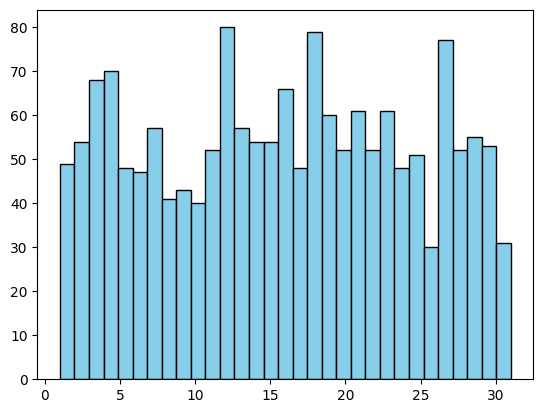

In [16]:
import matplotlib.pyplot as plt

# day_of_month_landslides.dropna()
plt.hist(day_of_month_landslides, bins=31, color='skyblue', edgecolor='black')

In [13]:
date_lengths = landslides['date'].str.len()
date_lengths.value_counts()

date
7.0    1075
6.0     368
8.0     247
Name: count, dtype: int64

In [15]:
indices = np.where([date_lengths == 6])[1]
print('Indices with corrupted data:', indices)
landslides.loc[indices].head()

Indices with corrupted data: [   0    2   11   12   13   16   29   30   31   32   33   34   35   36
   37   38   70   71   72   73   75   76   78   79   80   86   87   88
   97  103  104  105  111  112  113  114  124  125  126  127  128  129
  130  144  145  146  147  148  175  180  191  192  193  194  195  206
  207  252  253  254  255  256  257  258  259  260  261  262  293  294
  295  311  312  313  314  315  316  317  318  319  320  321  322  323
  324  325  326  327  328  329  330  331  332  333  334  335  336  337
  338  339  340  341  363  364  365  366  374  397  398  399  400  401
  402  403  404  405  406  435  436  437  438  439  440  576  577  584
  590  591  592  593  594  595  596  597  598  599  600  601  602  603
  604  623  624  625  626  627  683  684  685  686  687  688  689  690
  691  692  693  694  695  696  697  698  699  700  701  702  747  748
  749  750  751  752  753  763  764  765  766  767  768  769  770  771
  772  773  774  775  776  807  808  809  810  8

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link,date_parsed
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html,2007-03-02
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...,2007-04-06
11,109,7/1/07,NaN,NaN,United States,US,Texas,42409,Haltom City,0.03668,...,Landslide,Landslide,Medium,Rain,NaN,NaN,NaN,NBC5i.com,http://www.nbc5i.com/news/13604036/detail.html,2007-07-01
12,115,7/4/07,NaN,NaN,Mexico,MX,Veracruz-Llave,1947,Laguna Chica (Pueblo Nuevo),9.51003,...,Landslide,Landslide,Medium,Rain,NaN,NaN,7.0,nytimes.com,http://www.nytimes.com/2007/07/04/world/americ...,2007-07-04
13,119,7/8/07,NaN,NaN,Canada,CA,Ontario,812129,Ottawa,1.74759,...,Landslide,Landslide,Small,Unknown,NaN,NaN,NaN,NaN,http://www.cfra.com/headlines/index.asp?cat=1&...,2007-07-08


In [ ]:
# earthquakes.loc[3378, "Date"] = "02/23/1975"
# earthquakes.loc[7512, "Date"] = "04/28/1985"
# earthquakes.loc[20650, "Date"] = "03/13/2011"
# earthquakes['date_parsed'] = pd.to_datetime(earthquakes['Date'], format="%m/%d/%Y")
